# ISO-NE Interconnection Queue: Solar + Storage Analysis

This notebook cleans ISO New England's public interconnection queue and answers four questions about
solar and battery storage projects:

1. How much solar and storage capacity (MW) has been proposed in Massachusetts?
2. How long do projects sit in the queue?
3. What share of solar/storage projects get withdrawn?
4. How has the number of storage applications changed by year?

**Data source:** ISO-NE IRTT public queue report, <https://irtt.iso-ne.com/reports/external>,
downloaded 2026-09-30 (the page says "As of: 9/30/2026"). The page's "Export to Excel" button requires
an ISO-NE login, so we saved the public web page itself. It holds the same table the export would.

**Background: what is an interconnection queue?** Before a power plant can connect to the transmission
grid, the developer submits an *interconnection request* to the grid operator (here, ISO-NE). ISO-NE
studies whether the grid can handle the new plant and what upgrades are needed. Each request gets a
*queue position* (QP). A request ends in one of two ways: the project is built and starts operating
("commercial"), or the developer gives up ("withdrawn").

## 1. Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup   # parses the HTML page

# Folder paths, relative to this notebook (which lives in notebooks/)
ROOT = Path("..")
RAW_FILE = ROOT / "data" / "raw" / "iso_ne_public_queue_2026-09-30.html"
CLEAN_DIR = ROOT / "data" / "clean"
FIG_DIR = ROOT / "figures"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# The date the data was downloaded. Used as "today" when measuring how long
# still-active projects have been waiting.
AS_OF = pd.Timestamp("2026-09-30")

# One consistent color per project group, and per status, used in every chart
COLORS = {"Solar": "#E8A33D", "Storage": "#3B7DD8", "Solar + storage": "#2E9E6B", "All other": "#9AA0A6"}
STATUS_COLORS = {"active": "#3B7DD8", "in service": "#2E9E6B", "withdrawn": "#C9CDD2"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 2. Load the raw table

The page has one HTML table. Most cells hold plain text, but the study-progress columns (FS, SIS, IA,
Project Status...) show an **icon** instead of text. Each icon has a `title` attribute such as
`"Document Posted"`, so we read the title when a cell holds an image.

(`pd.read_html` would drop the icons, which is why we parse the page with BeautifulSoup.)

In [2]:
with open(RAW_FILE, encoding="utf-8") as f:
    soup = BeautifulSoup(f, "html.parser")

table = soup.find("table")

def cell_value(td):
    # Icon cells: return the icon's tooltip text. Other cells: return the text.
    img = td.find("img")
    if img is not None:
        return img.get("title", "")
    return td.get_text(strip=True)

headers = [th.get_text(strip=True) for th in table.find("thead").find_all("th")]
rows = [[cell_value(td) for td in tr.find_all("td")] for tr in table.find("tbody").find_all("tr")]

raw = pd.DataFrame(rows, columns=headers)
print(raw.shape)
raw.head()

(1751, 31)


,Cluster,QP,Updated,Type,Requested,Alternative Name,Unit,Fuel Type,Net MW,Summer MW,...,Dev,Zone,FS,SIS,OS,FAC,IA,Project Status,Status,Jurisdiction
0,TCS,1090,10/17/2025,G,1/13/2021,Park City Offshore Wind CNR,WT,WND,0,838.2,...,,SEMA,,,,,Executed,,A,F
1,TCS,1116,6/17/2026,G,4/13/2021,SouthCoast Wind 1,WT,WND,1200,1200,...,PD,RI,Document Posted,Document Posted,,,Executed,,A,F
2,TCS,1123,10/17/2025,G,4/21/2021,Naugatuck Avenue Battery Storage CNR Only (see...,OT,BAT,0,205.32,...,PD,SWCT,,,,,,,A,F
3,TCS,1148,4/8/2026,G,7/13/2021,Lite Brite Battery Storage,OT,BAT,300,305.624,...,,BOST,Document Posted,Document Posted,,,Executed,,A,F
4,TCS,1171,10/17/2025,G,10/25/2021,Twin Energy Wind,WT,WND,18.3,20,...,PD,ME,Document Posted,Document Posted,,,Executed,,A,F


## 3. Cleaning

### 3a. Standardize column names

We rename every column to a short `snake_case` name. **Decision:** the raw table has two columns both
called `SIS`. The first is a Y/N flag ("has the System Impact Study been completed?"). The second is
the study-progress icon. We call them `sis_complete` and `sis_study_status`. Because the names repeat,
we set the new names by position, in the same order as the page.

In [3]:
df = raw.copy()
df.columns = [
    "cluster",            # TCS = Transitional Cluster Study (ISO-NE's move to cluster studies)
    "queue_position",     # QP: ISO-NE's ID for the request
    "last_updated",
    "request_type",       # G = generator, ETU = elective transmission upgrade, TS = transmission service
    "request_date",       # date the request was submitted
    "project_name",
    "unit_type",          # PV = solar panels, WT = wind turbine, OT = other (mostly batteries), ...
    "fuel_type",          # EIA fuel codes, e.g. SUN, BAT, WND, NG
    "net_mw",             # net new MW injected at the connection point
    "summer_mw",          # capability in summer
    "winter_mw",          # capability in winter
    "county",
    "state",
    "op_date",            # commercial operation date (planned, or actual once built)
    "sync_date",          # date the unit first connects to the grid
    "withdrawal_date",
    "poi",                # point of interconnection (substation / line)
    "service_type",       # CNR = capacity network resource, NR = network resource (energy only), ...
    "sis_complete",       # Y/N
    "i39_approved",       # Y/N: approved under Tariff Section I.3.9 (no harm to reliability)
    "to_report",
    "dev",
    "planning_zone",      # ISO-NE planning sub-area; SEMA, WMA, BOST, CMA are in Massachusetts
    "fs_status",          # Feasibility Study progress icon
    "sis_study_status",   # System Impact Study progress icon
    "os_status",          # Optional Study progress icon
    "fac_status",         # Facilities Study progress icon
    "ia_status",          # Interconnection Agreement progress icon
    "project_status_icon",
    "status_code",        # A / C / W
    "jurisdiction",       # F = FERC, N = non-FERC
]
df.head(3)

,cluster,queue_position,last_updated,request_type,request_date,project_name,unit_type,fuel_type,net_mw,summer_mw,...,dev,planning_zone,fs_status,sis_study_status,os_status,fac_status,ia_status,project_status_icon,status_code,jurisdiction
0,TCS,1090,10/17/2025,G,1/13/2021,Park City Offshore Wind CNR,WT,WND,0,838.2,...,,SEMA,,,,,Executed,,A,F
1,TCS,1116,6/17/2026,G,4/13/2021,SouthCoast Wind 1,WT,WND,1200,1200,...,PD,RI,Document Posted,Document Posted,,,Executed,,A,F
2,TCS,1123,10/17/2025,G,4/21/2021,Naugatuck Avenue Battery Storage CNR Only (see...,OT,BAT,0,205.32,...,PD,SWCT,,,,,,,A,F


### 3b. Convert text to numbers and dates

Everything came in as text. We convert:

* **MW columns** to numbers. Blank cells become `NaN` (missing).
* **Date columns** (format `month/day/year`) to real dates. Blank cells become `NaT` (missing date).

`errors="coerce"` means "if a value can't be converted, mark it missing instead of crashing".
We also turn empty text cells into proper missing values, so counts of blanks are honest.

In [4]:
for col in ["queue_position", "net_mw", "summer_mw", "winter_mw"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["last_updated", "request_date", "op_date", "sync_date", "withdrawal_date"]:
    df[col] = pd.to_datetime(df[col], format="%m/%d/%Y", errors="coerce")

df = df.replace({"": pd.NA})

df[["net_mw", "summer_mw", "request_date", "op_date", "withdrawal_date"]].describe()

,net_mw,summer_mw,request_date,op_date,withdrawal_date
count,1473.000000,1482.000000,1751,1739,1187
mean,131.090689,162.372007,2015-08-07 23:59:10.656767,2019-04-27 15:27:25.773433,2020-03-22 03:50:29.823083
min,-21.200000,0.000000,1996-06-07 00:00:00,1999-05-01 00:00:00,2006-04-13 00:00:00
25%,4.990000,10.050000,2009-10-18 00:00:00,2013-12-02 00:00:00,2016-03-10 00:00:00
50%,20.000000,41.000000,2018-03-20 00:00:00,2021-07-15 00:00:00,2021-12-20 00:00:00
75%,109.799000,182.172500,2021-09-22 12:00:00,2025-02-25 12:00:00,2025-06-13 00:00:00
max,2400.000000,1600.000000,2025-01-14 00:00:00,2033-11-04 00:00:00,2026-09-18 00:00:00
std,269.179661,271.267065,NaN,NaN,NaN


### 3c. Map status codes to plain labels

The `status_code` column is the official status. The page's own filter menu defines the codes:

| Code | ISO-NE name | Our label | Meaning |
|---|---|---|---|
| `A` | Active | **active** | still in the queue |
| `C` | Commercial | **in service** | built and operating |
| `W` | Withdrawn | **withdrawn** | developer left the queue |

**Decision:** we do *not* use the `project_status_icon` column. It is out of date for many withdrawn
projects: the table below shows withdrawn projects that still carry an "Under Study" icon.

In [5]:
STATUS_LABELS = {"A": "active", "C": "in service", "W": "withdrawn"}
df["status"] = df["status_code"].map(STATUS_LABELS)

# Check: every row got a label
print(df["status"].value_counts(dropna=False))

# Show how stale the icon is
pd.crosstab(df["status"], df["project_status_icon"].fillna("(blank)"))

status
withdrawn     1329
in service     363
active          59
Name: count, dtype: int64


project_status_icon,(blank),In Service,Partially In Service,Suspended,Under Construction,Under Study
status,,,,,,
active,59,0,0,0,0,0
in service,246,111,3,0,3,0
withdrawn,1109,1,0,1,4,214


### 3d. Tag fuel type: solar, storage, or solar + storage

`fuel_type` holds one or more EIA fuel codes separated by spaces. `SUN` = solar, `BAT` = battery.
A project listing **both** is a hybrid (solar panels and a battery at the same site).

**Decisions:**

* `SUN` only → **Solar**
* `BAT` only → **Storage**
* `SUN` and `BAT` together, and nothing else → **Solar + storage** (hybrid)
* Everything else (wind, gas, hydro, wind + battery, ...) → **All other**. We keep these rows
  so solar/storage can be compared against the rest of the queue.
* A hybrid lists a single MW figure for the whole project, so we **don't split hybrid MW** between
  solar and storage. Hybrids are their own group.

In [6]:
def fuel_group(fuel_text):
    if pd.isna(fuel_text):
        return "All other"
    fuels = set(fuel_text.split())     # "SUN BAT" -> {"SUN", "BAT"}
    if fuels == {"SUN"}:
        return "Solar"
    if fuels == {"BAT"}:
        return "Storage"
    if fuels == {"SUN", "BAT"}:
        return "Solar + storage"
    return "All other"

df["fuel_group"] = df["fuel_type"].apply(fuel_group)

# Fix the order of the groups so every table and chart lists them the same way
GROUP_ORDER = ["Solar", "Storage", "Solar + storage", "All other"]
df["fuel_group"] = pd.Categorical(df["fuel_group"], categories=GROUP_ORDER, ordered=True)

df["fuel_group"].value_counts().sort_index()

fuel_group
Solar              380
Storage            274
Solar + storage    139
All other          958
Name: count, dtype: int64

### 3e. Tag state

**Decision:** we keep every state in the clean file and add an `is_massachusetts` flag, so the
Tableau dashboard can filter by any state. A few rows are in NY or New Brunswick (Canada): these are
transmission requests that connect New England to neighboring systems.

In [7]:
df["is_massachusetts"] = df["state"] == "MA"
df["state"].value_counts(dropna=False)

state
MA     605
ME     408
CT     323
NH     138
RI     123
VT     109
NaN     31
NY      13
NB       1
Name: count, dtype: int64

### 3f. Keep only generator requests for the analysis

`request_type` is `G` (generator), `ETU` (Elective Transmission Upgrade: new transmission lines,
often merchant lines importing power from Canada or New York) or `TS` (transmission service).

**Decision:** our questions are about power plants, so charts use only `G` rows. The clean CSV keeps
all rows plus an `is_generator` flag.

In [8]:
df["is_generator"] = df["request_type"] == "G"
df["request_type"].value_counts()

request_type
G      1569
ETU     170
TS       12
Name: count, dtype: int64

### 3g. Capacity (MW), avoiding double counting

There are three MW columns. **Decision:** we use **Summer MW** as project size. Summer capability is
what ISO-NE uses for capacity planning, since the grid peaks in summer. If Summer MW is blank we fall
back to Net MW.

**Double-counting problem:** some requests have **Net MW = 0**. These don't add new power to the
grid. Most ask for a new *service type* on a project already in the queue (e.g. *"Battery Storage CNR
Only (see QP1089)"*) or add equipment behind an existing connection. Their Summer MW repeats a
project already counted. **Decision:** we flag these as `is_zero_net_request` and exclude them from
every MW total. We still count them as applications.

(Trade-off: this also drops a few batteries added behind existing plants, so the MW totals are slightly
conservative.)

In [9]:
df["capacity_mw"] = df["summer_mw"].fillna(df["net_mw"])
df["is_zero_net_request"] = df["net_mw"] == 0

print("Requests with Net MW = 0:", df["is_zero_net_request"].sum())
df.loc[df["is_zero_net_request"], ["queue_position", "project_name", "fuel_type", "summer_mw", "status"]].head(8)

Requests with Net MW = 0: 152


,queue_position,project_name,fuel_type,summer_mw,status
0,1090,Park City Offshore Wind CNR,WND,838.20,active
2,1123,Naugatuck Avenue Battery Storage CNR Only (see...,BAT,205.32,active
187,115,SNEW Summer '04 Temporary Generator,DFO,23.80,withdrawn
212,137,Rumford Hydro Configuration Modification,WAT,NaN,in service
260,170,Gas Turbine Capacity Increase (see #155),DFO NG,40.00,withdrawn
272,181,Transmission Expansion,N/A,NaN,withdrawn
273,182,Gas Turbine Capacity Increase ( See queue posi...,DFO NG,0.00,withdrawn
304,201,Converts QP 164 to combined cycle facility and...,NG,162.00,withdrawn


### 3h. Time in queue

We measure **years from the request date to an end date**. For built projects the end date is the
**commercial operation date**. Withdrawn and active projects never reach operation, so they need
another end date:

| Status | End date | Why |
|---|---|---|
| in service | `op_date` (commercial operation) | the project finished the process and started operating |
| withdrawn | `withdrawal_date` | the project never operated; its time in the queue ends when it leaves |
| active | 2026-09-30 (download date) | still waiting, so this is a *lower bound* on its final time |

**Decisions:**

* Withdrawn projects with no withdrawal date, and in-service projects with no operation date, get a
  blank time (`NaN`) and drop out of the time chart only.
* A few in-service projects list an operation date *before* their request date. That's typical of
  existing plants filing for upgrades. We blank those negative values too.

In [10]:
end_date = pd.Series(pd.NaT, index=df.index)
end_date[df["status"] == "in service"] = df["op_date"]
end_date[df["status"] == "withdrawn"] = df["withdrawal_date"]
end_date[df["status"] == "active"] = AS_OF

df["years_in_queue"] = (end_date - df["request_date"]).dt.days / 365.25
print("Negative durations blanked:", (df["years_in_queue"] < 0).sum())
df.loc[df["years_in_queue"] < 0, "years_in_queue"] = float("nan")

df["request_year"] = df["request_date"].dt.year

df.groupby("status")["years_in_queue"].describe().round(1)

Negative durations blanked:

 5


,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
active,59.0,5.1,1.9,1.8,4.0,5.2,6.1,9.2
in service,355.0,3.0,2.1,0.0,1.4,2.6,4.5,10.7
withdrawn,1187.0,2.2,2.0,0.0,0.7,1.7,3.3,24.5


### 3i. Export the clean CSV

One row per interconnection request, with the new columns added. This file feeds the Tableau
dashboard. We drop the study-icon columns that are mostly blank and not used in the analysis.

In [11]:
clean_cols = [
    "queue_position", "project_name", "request_type", "is_generator", "cluster",
    "status", "status_code", "fuel_type", "fuel_group", "unit_type",
    "state", "is_massachusetts", "county", "planning_zone", "poi", "jurisdiction", "service_type",
    "capacity_mw", "net_mw", "summer_mw", "winter_mw", "is_zero_net_request",
    "request_date", "request_year", "op_date", "sync_date", "withdrawal_date", "years_in_queue",
    "sis_complete", "i39_approved", "ia_status", "last_updated",
]
clean = df[clean_cols].sort_values("queue_position")
clean.to_csv(CLEAN_DIR / "iso_ne_queue_clean.csv", index=False)
print(f"Saved {len(clean):,} rows x {len(clean_cols)} columns")

# Generator rows only, used by all four analyses below
gen = df[df["is_generator"]].copy()

Saved 1,751 rows x 32 columns


## 4. Analysis

### Q1. How much solar and storage capacity has been proposed in Massachusetts?

Only a few dozen projects are still *active* today, so a chart of active projects alone would be tiny.
Instead we show **every solar/storage MW ever requested in Massachusetts**, split by what happened:
still active, built (in service), or withdrawn. This shows what's pending *and* how much of the
proposed capacity actually got built.

In [12]:
ma = gen[gen["is_massachusetts"] & (gen["fuel_group"] != "All other") & ~gen["is_zero_net_request"]]
STATUS_ORDER = ["active", "in service", "withdrawn"]

ma_mw = (ma.pivot_table(index="fuel_group", columns="status", values="capacity_mw",
                        aggfunc="sum", observed=True)
           .reindex(columns=STATUS_ORDER).fillna(0))
ma_count = (ma.pivot_table(index="fuel_group", columns="status", values="queue_position",
                           aggfunc="count", observed=True)
              .reindex(columns=STATUS_ORDER).fillna(0).astype(int))
display(ma_mw.round(0))
display(ma_count)

status,active,in service,withdrawn
fuel_group,,,
Solar,0.0,135.0,562.0
Storage,4571.0,400.0,20659.0
Solar + storage,0.0,39.0,1104.0


status,active,in service,withdrawn
fuel_group,,,
Solar,0,19,46
Storage,17,2,141
Solar + storage,0,6,100


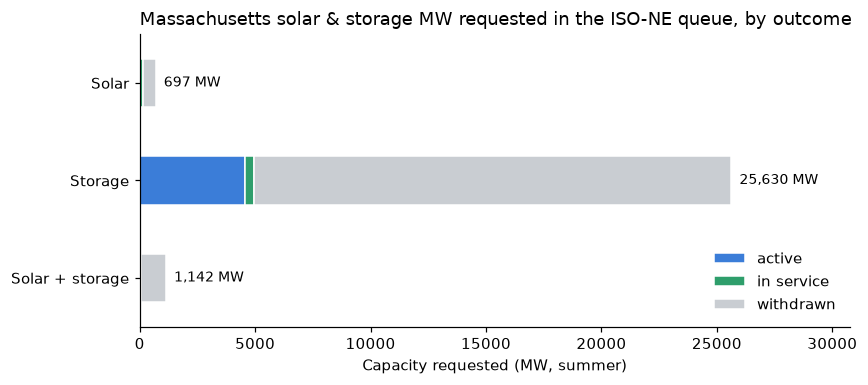

In [13]:
ax = ma_mw.plot(kind="barh", stacked=True, figsize=(8, 3.6),
                color=[STATUS_COLORS[c] for c in ma_mw.columns], edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Capacity requested (MW, summer)")
ax.set_ylabel("")
ax.set_title("Massachusetts solar & storage MW requested in the ISO-NE queue, by outcome", loc="left")
# Label each bar with its total
for i, total in enumerate(ma_mw.sum(axis=1)):
    ax.text(total, i, f"  {total:,.0f} MW", va="center", fontsize=9)
ax.set_xlim(0, ma_mw.sum(axis=1).max() * 1.2)
ax.legend(title="", frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "q1_ma_capacity_by_status.png", bbox_inches="tight")
plt.show()

### Q2. How long do projects sit in the queue?

Median years in the queue, by project group and outcome. We use the **median**, not the mean, because
a few projects sat for over a decade and would pull the average up.

In [14]:
q2 = (gen.dropna(subset=["years_in_queue"])
         .groupby(["fuel_group", "status"], observed=True)["years_in_queue"]
         .agg(["median", "count"]))
display(q2.round(1))

q2_median = q2["median"].unstack("status").reindex(columns=["in service", "withdrawn", "active"])

median  count
fuel_group      status                   
Solar           active         5.6     21
                in service     2.6     62
                withdrawn      2.1    292
Storage         active         4.0     23
                in service     6.8      4
                withdrawn      1.3    247
Solar + storage active         4.4      1
                in service     2.2     11
                withdrawn      3.0    127
All other       active         5.6      8
                in service     2.5    273
                withdrawn      1.9    394

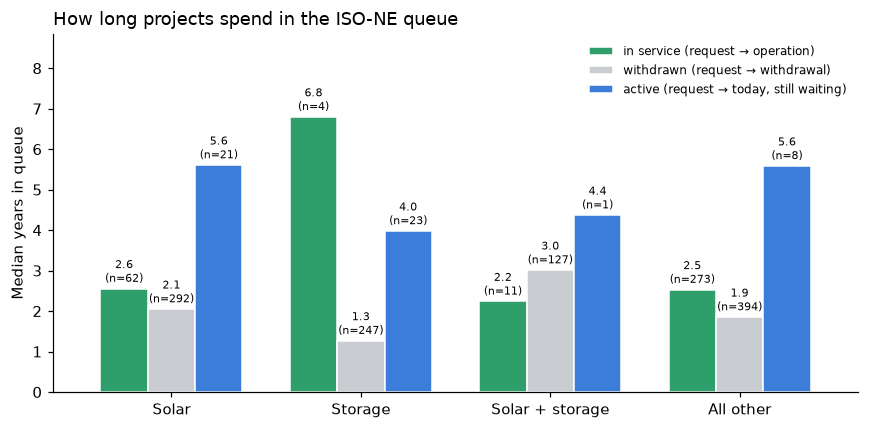

In [15]:
ax = q2_median.plot(kind="bar", figsize=(8, 4), rot=0, width=0.75,
                    color=[STATUS_COLORS[c] for c in q2_median.columns], edgecolor="white")
ax.set_ylabel("Median years in queue")
ax.set_xlabel("")
ax.set_title("How long projects spend in the ISO-NE queue", loc="left")
# Label each bar with its median and the number of projects behind it (n).
# Small n (e.g. only 4 storage projects are in service) means that median is not reliable.
q2_count = q2["count"].unstack("status").reindex(columns=q2_median.columns)
for container, status in zip(ax.containers, q2_median.columns):
    labels = [f"{m:.1f}\n(n={n:.0f})" if pd.notna(m) else "" for m, n in zip(q2_median[status], q2_count[status])]
    ax.bar_label(container, labels=labels, fontsize=7, padding=2)
ax.set_ylim(0, q2_median.max().max() * 1.3)
ax.legend(["in service (request → operation)", "withdrawn (request → withdrawal)",
           "active (request → today, still waiting)"], frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "q2_time_in_queue.png", bbox_inches="tight")
plt.show()

### Q3. What share of solar/storage projects get withdrawn?

**Decision:** we only count projects that have *finished* their time in the queue, meaning they were
built or withdrew. Active projects haven't had an outcome yet, and counting them would make the
withdrawal rate look lower than it is.

In [16]:
finished = gen[gen["status"].isin(["in service", "withdrawn"])]
q3 = (finished.groupby("fuel_group", observed=True)["status"]
              .agg(withdrawn=lambda s: (s == "withdrawn").sum(), total="count"))
q3["pct_withdrawn"] = 100 * q3["withdrawn"] / q3["total"]
q3.round(1)

,withdrawn,total,pct_withdrawn
fuel_group,,,
Solar,295,359,82.2
Storage,247,251,98.4
Solar + storage,127,138,92.0
All other,489,768,63.7


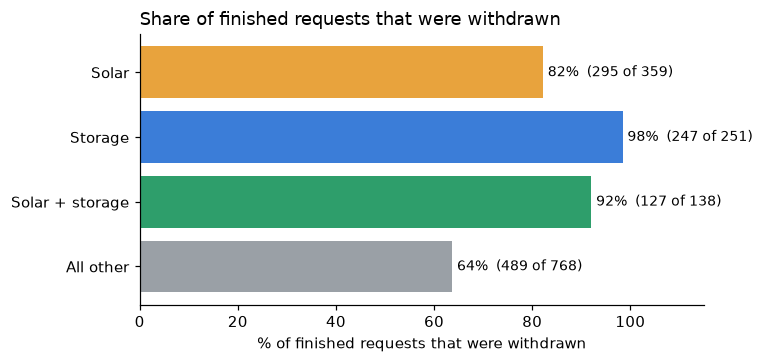

In [17]:
fig, ax = plt.subplots(figsize=(7, 3.4))
bars = ax.barh(q3.index.astype(str), q3["pct_withdrawn"], color=[COLORS[g] for g in q3.index])
ax.invert_yaxis()
ax.set_xlim(0, 115)
ax.set_xticks(range(0, 101, 20))
ax.set_xlabel("% of finished requests that were withdrawn")
ax.set_title("Share of finished requests that were withdrawn", loc="left")
for bar, (_, row) in zip(bars, q3.iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{row.pct_withdrawn:.0f}%  ({row.withdrawn:.0f} of {row.total:.0f})", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "q3_withdrawal_rate.png", bbox_inches="tight")
plt.show()

### Q4. How has the number of storage applications changed by year?

We count requests with a battery (**Storage** and **Solar + storage**) by the year they were submitted.
We count *applications* (all of them, including Net MW = 0 add-on requests), not MW.

**Caution about 2025:** the data has only one request in 2025. ISO-NE switched from a first-come,
first-served queue to **cluster studies** (FERC Order 2023). New requests now come in through cluster
request windows, which don't appear to be on this report. The drop after 2024 reflects that change,
not a collapse in developer interest.

In [18]:
battery = gen[gen["fuel_group"].isin(["Storage", "Solar + storage"])]
q4 = (battery.groupby(["request_year", "fuel_group"], observed=True).size()
             .unstack("fuel_group").fillna(0).astype(int))
q4 = q4.reindex(range(int(q4.index.min()), 2026), fill_value=0)   # include years with zero requests
q4

fuel_group,Storage,Solar + storage
request_year,,
2015,1,0
2016,0,0
2017,4,1
2018,7,3
2019,12,7
2020,13,34
2021,35,29
2022,50,41
2023,77,11


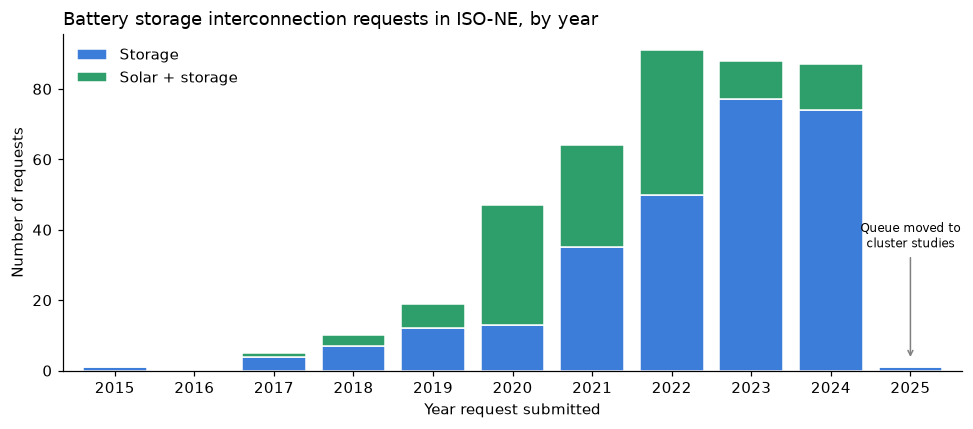

In [19]:
ax = q4.plot(kind="bar", stacked=True, figsize=(9, 4), width=0.8, rot=0,
             color=[COLORS[c] for c in q4.columns], edgecolor="white")
ax.set_xlabel("Year request submitted")
ax.set_ylabel("Number of requests")
ax.set_title("Battery storage interconnection requests in ISO-NE, by year", loc="left")
ax.legend(title="", frameon=False, loc="upper left")
ax.annotate("Queue moved to\ncluster studies", xy=(len(q4) - 1, 3), xytext=(len(q4) - 1, 35),
            fontsize=8, ha="center", arrowprops=dict(arrowstyle="->", color="gray"))
plt.tight_layout()
plt.savefig(FIG_DIR / "q4_storage_requests_by_year.png", bbox_inches="tight")
plt.show()

## 5. Headline numbers for the README

In [20]:
print("Total requests:", len(df), "| generator requests:", len(gen))
print(gen["status"].value_counts().to_dict())
print("\nMA solar/storage MW by status:", ma_mw.sum().round(0).to_dict(), "| total:", round(ma_mw.values.sum()))
print("MA MW by group (all statuses):", ma_mw.sum(axis=1).round(0).to_dict())
print("MA active MW by group:", ma_mw["active"].round(0).to_dict())
print("\nMedian years in queue:\n", q2_median.round(1).to_string())
print("\nWithdrawal rate %:", q3["pct_withdrawn"].round(0).to_dict())
print("\nBattery requests by year:", q4.sum(axis=1).to_dict())
print("\nGenerator withdrawals by year:", gen["withdrawal_date"].dt.year.value_counts().sort_index().tail(5).to_dict())

Total requests: 1751 | generator requests: 1569
{'withdrawn': 1158, 'in service': 358, 'active': 53}

MA solar/storage MW by status: {'active': 4571.0, 'in service': 574.0, 'withdrawn': 22325.0} | total: 27470
MA MW by group (all statuses): {'Solar': 697.0, 'Storage': 25630.0, 'Solar + storage': 1142.0}
MA active MW by group: {'Solar': 0.0, 'Storage': 4571.0, 'Solar + storage': 0.0}

Median years in queue:
 status           in service  withdrawn  active
fuel_group                                    
Solar                   2.6        2.1     5.6
Storage                 6.8        1.3     4.0
Solar + storage         2.2        3.0     4.4
All other               2.5        1.9     5.6

Withdrawal rate %: {'Solar': 82.0, 'Storage': 98.0, 'Solar + storage': 92.0, 'All other': 64.0}

Battery requests by year: {2015: 1, 2016: 0, 2017: 5, 2018: 10, 2019: 19, 2020: 47, 2021: 64, 2022: 91, 2023: 88, 2024: 87, 2025: 1}

Generator withdrawals by year: {2022.0: 52, 2023.0: 57, 2024.0: 95, 2025.0: